# Experiments

Gender-balance sweep and a vision-type super-mutant invasion, both measured against the
stable benchmark **M\***.

Nothing here touches `dating_market.py` or `StrategyTest.ipynb`.

**Runtime** — the full sweep is ~10–20 min; the 100%-vision points are the slow ones.
Set `QUICK = True` in the config cell for a ~1-min smoke test first.

**Two fitness axes are reported throughout:**
- `throughput` — per-agent cumulative compatibility over the steady-state window
  (singles contribute 0). Rewards being matched, often, and well. Not normalised.
  *(Relationships are fixed-length in this model, so this is clean time-in-good-matches;
  no compatibility-squared weighting.)*
- `welfare_ratio` — realised per-capita quality ÷ M\* per-capita quality, in [0, 1].
  Structural, normalised, comparable across conditions.

Plus structural stability: `partner_frac` (exact-M\* partner among matched) and
`blocking_frac` (blocking pairs ÷ all opposite-gender pairs).

In [10]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)  # cosmetic empty-slice/0-var noise

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matching_metrics import InstrumentedDatingMarket

# ---- toggle a fast smoke test vs the full sweep ----
QUICK = False

# fixed strategy + world parameters (held constant across BOTH experiments)
BASE  = dict(rejection_cost=1.0, rationality=6.0, relation_threshold=0.6,
             memory_depth=8, move_prob=0.5)
MODEL = dict(interaction_std=0.5, interaction_radius=5, relationship_length=10)

if QUICK:
    N, N_GRID, N_STEPS, BURN_IN = 120, 45, 90, 45
    SEEDS_BAL = range(3); SEEDS_MUT = range(3)
    BALANCES  = [0.5, 0.7, 0.8]
    FRACS     = [0.0, 0.15, 0.5, 1.0]
else:
    N, N_GRID, N_STEPS, BURN_IN = 120, 45, 160, 70
    SEEDS_BAL = range(20); SEEDS_MUT = range(12)
    BALANCES  = [0.5, 0.55, 0.6, 0.7, 0.8]
    FRACS     = [0.0, 0.05, 0.15, 0.35, 0.65, 1.0]

In [11]:
# Vision-type mutant: unrestricted sensing range. The ONLY difference from a resident is
# that neighbours() returns the whole population, so it can observe and propose anywhere.
class VisionMarket(InstrumentedDatingMarket):
    def neighbours(self, agent_id):
        if getattr(self.subjects[agent_id], "full_vision", False):
            return [a.id for a in self.subjects if a.id != agent_id]
        return super().neighbours(agent_id)

In [12]:
def simulate(m, groups, n_steps, burn_in):
    """Step the model; over the steady-state window collect per-group and market metrics.

    groups : {name: np.array(agent_ids)}.  Returns {name: {...}, "_market": {...}}.
    """
    acc = {g: dict(cum=0.0, wr=[], pf=[], mf=[], wc=[]) for g in groups}
    mkt = dict(wr=[], block=[], pf=[])
    npair = sum(a.is_male for a in m.subjects) * sum(not a.is_male for a in m.subjects)
    nwin = 0
    for t in range(n_steps):
        m.step()
        if t < burn_in:
            continue
        nwin += 1
        glob = m.stable_global()
        realized = {a.id: a.partner for a in m.subjects
                    if not a.is_single and a.partner is not None}
        om = m.matching_metrics()                       # market vs global M*
        mkt["wr"].append(om["welfare_ratio"])
        mkt["block"].append(om["blocking_pairs"] / npair)
        mkt["pf"].append(om["partner_frac_matched"])
        for g, ids in groups.items():
            a = acc[g]
            a["cum"] += sum(m.agent_quality(m.subjects[i]) for i in ids)       # throughput
            a["mf"].append(np.mean([not m.subjects[i].is_single for i in ids]))
            r = s = 0.0
            for i in ids:
                if i in realized:
                    j = realized[i]; r += m._compat[(i, j)] if m.subjects[i].is_male else m._compat[(j, i)]
                if i in glob:
                    j = glob[i];     s += m._compat[(i, j)] if m.subjects[i].is_male else m._compat[(j, i)]
            a["wr"].append(r / s if s > 0 else np.nan)
            gm = [i for i in ids if i in realized]
            a["pf"].append(np.mean([glob.get(i) == realized[i] for i in gm]) if gm else np.nan)
            # winner's curse: current memory estimate minus true compatibility, matched only
            gaps = []
            for i in gm:
                ag = m.subjects[i]
                if ag.partner in ag._buf:
                    est  = ag.samples(ag.partner).mean()
                    true = m._compat[(i, ag.partner)] if ag.is_male else m._compat[(ag.partner, i)]
                    gaps.append(est - true)
            if gaps:
                a["wc"].append(np.mean(gaps))
    out = {}
    for g, ids in groups.items():
        a = acc[g]; denom = len(ids) * max(nwin, 1)
        out[g] = dict(throughput=(a["cum"] / denom) if denom else np.nan,
                      welfare_ratio=np.nanmean(a["wr"]) if a["wr"] else np.nan,
                      partner_frac=np.nanmean(a["pf"]) if a["pf"] else np.nan,
                      matched_frac=np.nanmean(a["mf"]) if a["mf"] else np.nan,
                      winners_curse=np.nanmean(a["wc"]) if a["wc"] else np.nan)
    out["_market"] = dict(welfare_ratio=np.nanmean(mkt["wr"]),
                          blocking_frac=np.nanmean(mkt["block"]),
                          partner_frac=np.nanmean(mkt["pf"]))
    return out


def agg(df, by):
    """mean and standard error across seeds."""
    g = df.groupby(by)
    return g.mean(numeric_only=True), g.sem(numeric_only=True)

In [13]:
def run_balance(balance, seed):
    m = InstrumentedDatingMarket(n_grid=N_GRID, seed=seed, **MODEL)
    m.add_agents(N, gender_balance=balance, label="pop", **BASE)
    mal = np.array([a.id for a in m.subjects if a.is_male])
    fem = np.array([a.id for a in m.subjects if not a.is_male])
    maj, mnr = (mal, fem) if len(mal) >= len(fem) else (fem, mal)   # majority / minority side
    d = simulate(m, {"maj": maj, "min": mnr}, N_STEPS, BURN_IN)
    return dict(balance=balance, seed=seed,
                maj_mf=d["maj"]["matched_frac"], min_mf=d["min"]["matched_frac"],
                maj_through=d["maj"]["throughput"], min_through=d["min"]["throughput"],
                mkt_wr=d["_market"]["welfare_ratio"], mkt_pf=d["_market"]["partner_frac"],
                mkt_block=d["_market"]["blocking_frac"])


def run_mutant(frac, seed):
    k = int(round(frac * N))
    m = VisionMarket(n_grid=N_GRID, seed=seed, **MODEL)
    groups = {}
    if N - k > 0:
        rid = m.add_agents(N - k, gender_balance=0.5, label="resident", **BASE)
        groups["res"] = np.array([a.id for a in m.subjects if a.strategy_id == rid])
    if k > 0:
        mid = m.add_agents(k, gender_balance=0.5, label="mutant", **BASE)
        for a in m.subjects:
            if a.strategy_id == mid:
                a.full_vision = True                     # the only change vs residents
        groups["mut"] = np.array([a.id for a in m.subjects if a.strategy_id == mid])
    d = simulate(m, groups, N_STEPS, BURN_IN); nan = float("nan")
    res, mut = d.get("res", {}), d.get("mut", {})
    return dict(frac=frac, seed=seed,
                res_through=res.get("throughput", nan), mut_through=mut.get("throughput", nan),
                res_wr=res.get("welfare_ratio", nan),   mut_wr=mut.get("welfare_ratio", nan),
                res_pf=res.get("partner_frac", nan),    mut_pf=mut.get("partner_frac", nan),
                mut_wc=mut.get("winners_curse", nan),
                mkt_wr=d["_market"]["welfare_ratio"], mkt_block=d["_market"]["blocking_frac"])

## Experiment 1 — gender balance

One homogeneous population (baseline strategy) at each balance. `gender_balance` is the
male fraction; by symmetry we report **majority vs minority side** rather than male/female.

**Read the metrics by level, not by side for everything:**
- `matched_fraction` and `throughput` are **per-side** — they divide by each group's size and
  count singles as 0, so they expose the overcrowding penalty on the majority.
- `welfare_ratio` and `partner_frac` are **market-level**: every couple is shared by both
  sides, so per-side versions are identical by construction. Report them once for the market.

In [14]:
rows_bal = [run_balance(b, s) for b in BALANCES for s in SEEDS_BAL]
df_bal = pd.DataFrame(rows_bal)
mean_bal, sem_bal = agg(df_bal, "balance")
mean_bal[["maj_mf","min_mf","maj_through","min_through","mkt_wr","mkt_pf","mkt_block"]].round(3)

,maj_mf,min_mf,maj_through,min_through,mkt_wr,mkt_pf,mkt_block
balance,,,,,,,
0.50,0.704,0.704,0.581,0.581,0.623,0.051,0.152
0.55,0.640,0.782,0.530,0.648,0.667,0.062,0.147
0.60,0.551,0.826,0.456,0.684,0.699,0.053,0.149
0.70,0.369,0.861,0.305,0.711,0.723,0.048,0.163
0.80,0.221,0.882,0.183,0.732,0.741,0.043,0.171


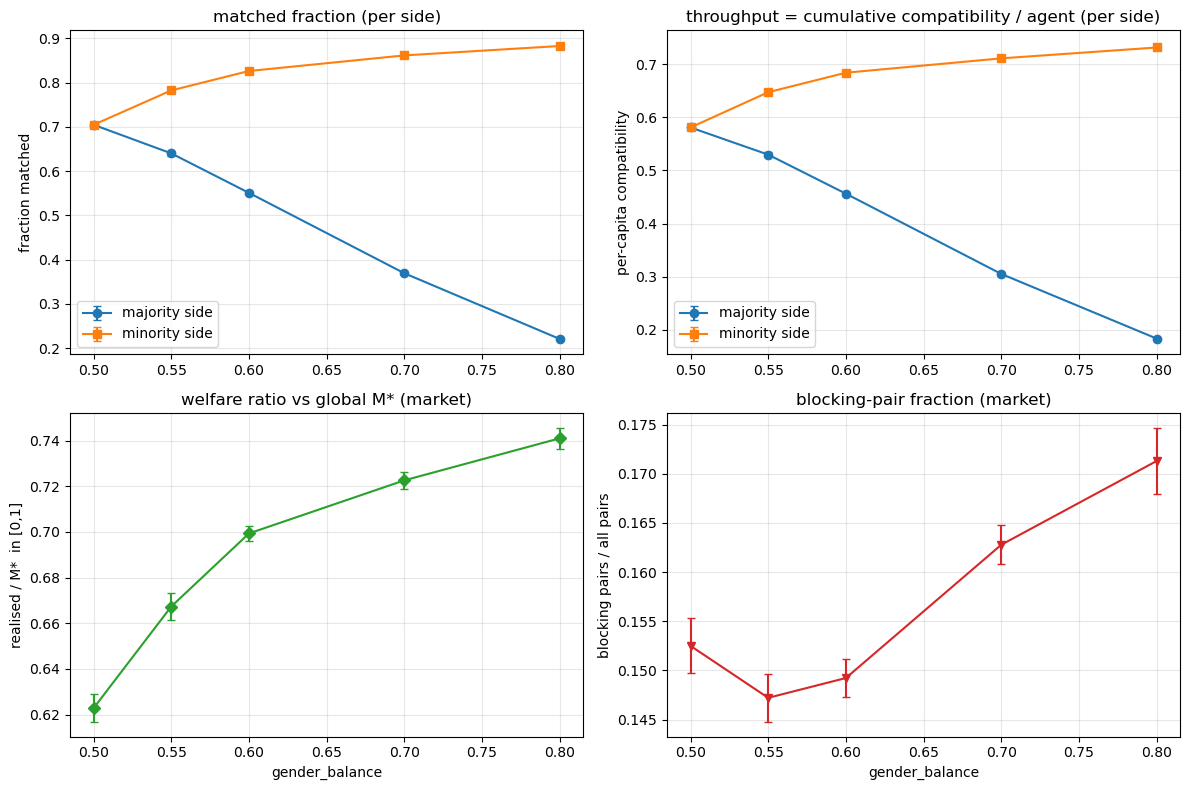

In [15]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
x = mean_bal.index.values

ax[0,0].errorbar(x, mean_bal["maj_mf"], yerr=sem_bal["maj_mf"], marker="o", capsize=3, label="majority side")
ax[0,0].errorbar(x, mean_bal["min_mf"], yerr=sem_bal["min_mf"], marker="s", capsize=3, label="minority side")
ax[0,0].set_title("matched fraction (per side)"); ax[0,0].set_ylabel("fraction matched")
ax[0,0].legend(); ax[0,0].grid(alpha=.3)

ax[0,1].errorbar(x, mean_bal["maj_through"], yerr=sem_bal["maj_through"], marker="o", capsize=3, label="majority side")
ax[0,1].errorbar(x, mean_bal["min_through"], yerr=sem_bal["min_through"], marker="s", capsize=3, label="minority side")
ax[0,1].set_title("throughput = cumulative compatibility / agent (per side)")
ax[0,1].set_ylabel("per-capita compatibility"); ax[0,1].legend(); ax[0,1].grid(alpha=.3)

ax[1,0].errorbar(x, mean_bal["mkt_wr"], yerr=sem_bal["mkt_wr"], marker="D", capsize=3, color="C2")
ax[1,0].set_title("welfare ratio vs global M* (market)")
ax[1,0].set_ylabel("realised / M*  in [0,1]"); ax[1,0].set_xlabel("gender_balance"); ax[1,0].grid(alpha=.3)

ax[1,1].errorbar(x, mean_bal["mkt_block"], yerr=sem_bal["mkt_block"], marker="v", capsize=3, color="C3")
ax[1,1].set_title("blocking-pair fraction (market)")
ax[1,1].set_ylabel("blocking pairs / all pairs"); ax[1,1].set_xlabel("gender_balance"); ax[1,1].grid(alpha=.3)

plt.tight_layout(); plt.show()

## Experiment 2 — vision-type super-mutant

A mutant is a baseline agent with **one capability change: unrestricted vision** (it senses
and can propose to the whole grid). Everything else — `rejection_cost`, `rationality`,
threshold, memory — is identical to residents, so any difference is attributable to vision
alone. Mutants are split 50/50 across genders; overall balance stays 0.5.

Two questions, two designs:
- **Invasion (rare mutant):** one mutant among residents — its private fitness, and whether
  residents are measurably harmed.
- **Frequency dependence:** sweep the mutant share 0 → 100% — does any private edge persist
  as it spreads, and what happens to overall market structure?

**What to look for (not assume):** compare the mutant and resident lines. If they diverge
(mutant up, residents down) that's a preemption externality — private gain at others' expense.
If residents *also* rise, vision is an efficiency spillover rather than pure rivalry. The
market lines (`mkt_wr`, `mkt_block`) and the winner's-curse panel tell you which.

**Caveat:** full vision is a *capability endowment*, not a learnable strategy, so this is not
a clean ESS/invasion-fitness test — it measures market power and search/information value,
not strategic invadability.

In [16]:
# Invasion case: exactly one rare mutant vs the all-resident baseline.
inv = pd.DataFrame([{**run_mutant(0.0, s), "case": "0 mutants"} for s in SEEDS_MUT]
                   + [{**run_mutant(1.0 / N, s), "case": "1 mutant"} for s in SEEDS_MUT])
inv.groupby("case")[["res_through","mut_through","res_wr","mut_wr","mut_wc","mkt_wr","mkt_block"]].mean().round(3)

,res_through,mut_through,res_wr,mut_wr,mut_wc,mkt_wr,mkt_block
case,,,,,,,
0 mutants,0.585,NaN,0.628,NaN,NaN,0.628,0.151
1 mutant,0.599,0.735,0.642,0.768,0.047,0.644,0.140


In [17]:
rows_mut = [run_mutant(f, s) for f in FRACS for s in SEEDS_MUT]
df_mut = pd.DataFrame(rows_mut)
mean_mut, sem_mut = agg(df_mut, "frac")
mean_mut[["res_through","mut_through","res_wr","mut_wr","mut_wc","mkt_wr","mkt_block"]].round(3)

,res_through,mut_through,res_wr,mut_wr,mut_wc,mkt_wr,mkt_block
frac,,,,,,,
0.00,0.585,NaN,0.628,NaN,NaN,0.628,0.151
0.05,0.590,0.740,0.633,0.783,0.040,0.641,0.147
0.15,0.611,0.739,0.655,0.800,0.039,0.676,0.131
0.35,0.640,0.741,0.685,0.797,0.038,0.724,0.114
0.65,0.663,0.746,0.707,0.801,0.034,0.768,0.103
1.00,NaN,0.747,NaN,0.801,0.026,0.801,0.100


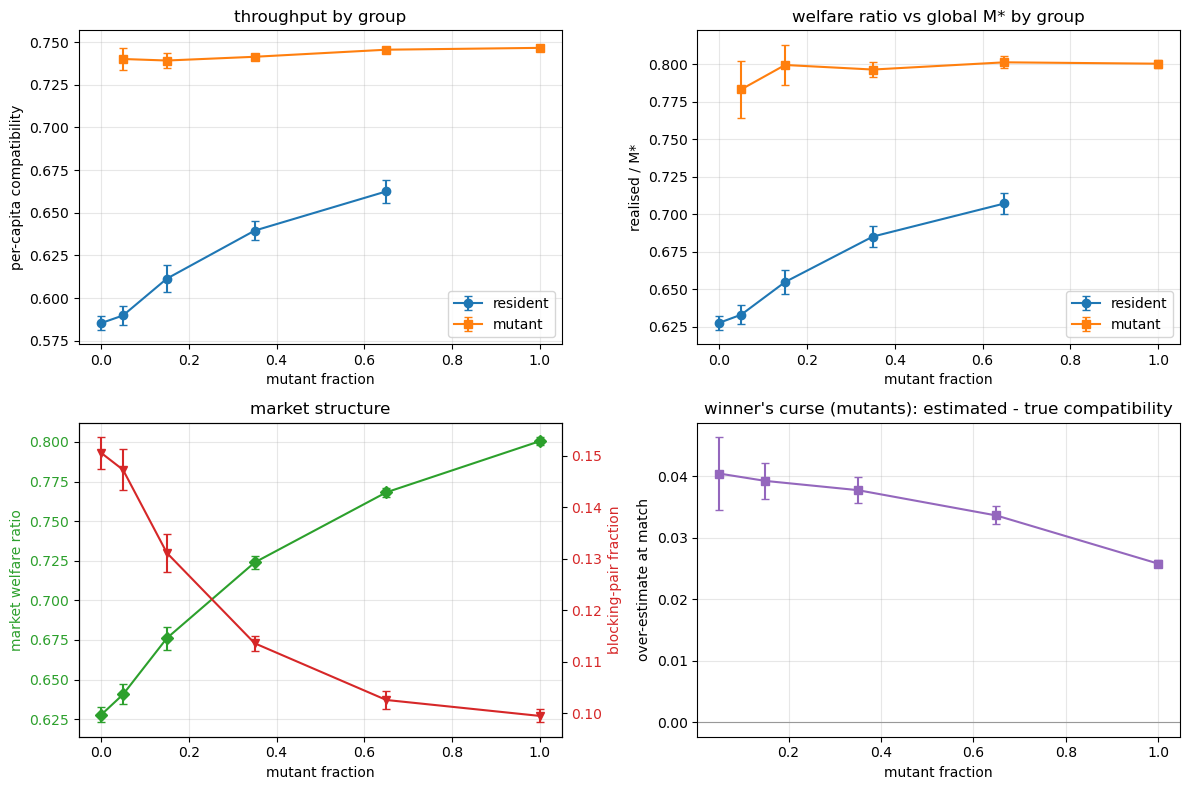

In [18]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
x = mean_mut.index.values

ax[0,0].errorbar(x, mean_mut["res_through"], yerr=sem_mut["res_through"], marker="o", capsize=3, label="resident")
ax[0,0].errorbar(x, mean_mut["mut_through"], yerr=sem_mut["mut_through"], marker="s", capsize=3, label="mutant")
ax[0,0].set_title("throughput by group"); ax[0,0].set_ylabel("per-capita compatibility")
ax[0,0].set_xlabel("mutant fraction"); ax[0,0].legend(); ax[0,0].grid(alpha=.3)

ax[0,1].errorbar(x, mean_mut["res_wr"], yerr=sem_mut["res_wr"], marker="o", capsize=3, label="resident")
ax[0,1].errorbar(x, mean_mut["mut_wr"], yerr=sem_mut["mut_wr"], marker="s", capsize=3, label="mutant")
ax[0,1].set_title("welfare ratio vs global M* by group"); ax[0,1].set_ylabel("realised / M*")
ax[0,1].set_xlabel("mutant fraction"); ax[0,1].legend(); ax[0,1].grid(alpha=.3)

ax[1,0].errorbar(x, mean_mut["mkt_wr"], yerr=sem_mut["mkt_wr"], marker="D", capsize=3, color="C2", label="welfare ratio")
ax[1,0].set_ylabel("market welfare ratio", color="C2"); ax[1,0].tick_params(axis="y", labelcolor="C2")
axb = ax[1,0].twinx()
axb.errorbar(x, mean_mut["mkt_block"], yerr=sem_mut["mkt_block"], marker="v", capsize=3, color="C3", label="blocking frac")
axb.set_ylabel("blocking-pair fraction", color="C3"); axb.tick_params(axis="y", labelcolor="C3")
ax[1,0].set_title("market structure"); ax[1,0].set_xlabel("mutant fraction"); ax[1,0].grid(alpha=.3)

ax[1,1].errorbar(x, mean_mut["mut_wc"], yerr=sem_mut["mut_wc"], marker="s", capsize=3, color="C4")
ax[1,1].axhline(0, color="0.6", lw=.8)
ax[1,1].set_title("winner's curse (mutants): estimated - true compatibility")
ax[1,1].set_ylabel("over-estimate at match"); ax[1,1].set_xlabel("mutant fraction"); ax[1,1].grid(alpha=.3)

plt.tight_layout(); plt.show()

## Notes & caveats

- **`welfare_ratio` is market-level in Experiment 1.** Per-side versions are identical by
  construction (couples are shared), so the majority/minority story lives entirely in
  `matched_fraction` and `throughput`.
- **Benchmark choice by object.** Mutants have global reach → judge them against global M\*.
  Residents are local → their realised-vs-reachable gap is fairer against the spatial M\*
  (`m.spatial_metrics()`); add it if you want to separate geography from strategy for residents.
- **Reproducibility.** `InstrumentedDatingMarket` freezes the true-value matrix up front with a
  separate RNG, so a given seed is reproducible here but the trajectory does **not** match the
  base `DatingMarket` for the same seed. Re-run all M\* analysis with the instrumented class;
  don't graft these numbers onto StrategyTest's existing sweeps.
- **Steady state.** Confirm the window is past burn-in by eyeballing a metric's time series for
  one run before trusting the averages; imbalance and high mutant fractions can shift settling time.
- **Cost.** The 100%-vision point is O(n²) per step (everyone senses everyone). If the full sweep
  is too slow, drop `frac=1.0`, lower `SEEDS_MUT`, or reduce `N`.